# Stage A — Held-out AERONET validation (§8.1.1, §8.1.4, §8.1.5)

Headline tests of the **30-min `AOD_merged`** product on the *held-out* window
**Jan 2025 – Apr 2026**.  Nothing in this notebook participates in any training
step — every fit (CDFs, soft-calibration, post-correction RMSE table) was
built on Sep 2022 – Dec 2024 (see `validate_bias_correction.ipynb` for §8.1.2).

| Block | Plan section | Pass criteria |
|---|---|---|
| §1 — matched pairs | §8.1.1 setup | merged-AERONET pairs at the two station 0.05° cells, ±30 min temporal window |
| §2 — overall metric panel | §8.1.1 | N, R, R², RMSE, MAE, Bias, %EE per (site × season × confidence_flag) |
| §3 — per-station scatter | §8.1.1 Gupta 2024 Fig. 10 analogue | merged scatter inside best-single-sensor envelope |
| §4 — pass-criterion gate | §8.1.1 → §9 | Nghia Do `R ≥ 0.90, RMSE ≤ 0.30`; Bac Lieu `R ≥ 0.85, RMSE ≤ 0.20`; dry-season \|Bias\| ≤ 0.05 |
| §5 — confidence-flag monotonicity | §8.1.1 | R should be monotonic across flag = 1 → 2 → 3 → 4 |
| §6 — precipitation-aware (§8.1.5) | §8.1.5 | dry > 24 h since rain, recovery 12–24 h, post-rain 0–12 h.  Dry R ≥ 0.85 at both stations |
| §7 — baselines (§8.1.4) | §8.1.4 | merged must beat B1 (best single sensor), B2 (Gupta 2024 equal-weight DT merge), and B3 (Ahn 2021 NE Asia ICW) on R / RMSE / %EE at *at least one* station for *at least one* season |

The functions doing the heavy lifting live in [validate.py](validate.py):
`extract_aeronet_pairs`, `stratified_metrics`, `compute_metrics`,
`precip_aware_validation`, `baseline_comparison`,
`compute_per_sensor_aeronet_rmse`.


## 0. Setup

In [1]:
from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (
    AERONET_SITES, DRY_MONTHS,
    TRAIN_START, TRAIN_END,
    TEST_START, TEST_END,
)
from validate import (
    extract_aeronet_pairs,
    stratified_metrics,
    compute_metrics,
    precip_aware_validation,
    precip_label_pairs,
    baseline_comparison,
)

# §9 targets (the numbers the headline check compares against)
TARGETS = {
    'NGHIA_DO': {'R_min': 0.90, 'RMSE_max': 0.30, 'Bias_abs_max_dry': 0.05},
    'Bac_Lieu': {'R_min': 0.85, 'RMSE_max': 0.20, 'Bias_abs_max_dry': 0.05},
}

start, end = TEST_START, TEST_END
print(f'Held-out window: {start} → {end}')
print(f'Sites          : {list(AERONET_SITES)}')


Held-out window: 2025-01-01 → 2026-04-30
Sites          : ['NGHIA_DO', 'Bac_Lieu']


## 1. Matched (merged, AERONET) pairs over the held-out window

For each 30-min merged NetCDF in `[TEST_START, TEST_END]`, sample `AOD_merged`
at each AERONET station's 0.05° cell and pair it with the mean AERONET 550 nm
AOD in the ±30 min window centred on the slot.  Skips slots where the cell has
no merged value, where no AERONET observation is in the window, or where the
merged NetCDF is missing on disk.


In [2]:
pairs = extract_aeronet_pairs(start, end)

if pairs.empty:
    print('No matched pairs found.  Check MERGED_DIR contents and date range.')
else:
    print(f'  {len(pairs):,} matched pairs')
    print(f'  date span : {pairs["slot_utc"].min()} → {pairs["slot_utc"].max()}')
    print()
    print('Per-site counts:')
    print(pairs.groupby(['site', 'season'])['merged_aod'].count()
            .unstack(fill_value=0).to_string())
    print()
    print('Per confidence flag:')
    print(pairs.groupby(['site', 'confidence_flag'])['merged_aod']
            .count().unstack(fill_value=0).to_string())
pairs.head()


Matching AERONET pairs: 100%|████████████| 9212/9212 [00:44<00:00, 208.10file/s]

  1,019 matched pairs
  date span : 2025-01-04 04:00:00 → 2026-04-30 05:30:00

Per-site counts:
season    dry  wet
site              
Bac_Lieu  324   81
NGHIA_DO  532   82

Per confidence flag:
confidence_flag    1    2   3  4
site                            
Bac_Lieu         103  293   9  0
NGHIA_DO         280  292  36  6


,slot_utc,site,region,season,month,merged_aod,aeronet_aod,confidence_flag,n_sensors,aeronet_n_obs,box_std,spatial_flag
0,2025-01-04 04:00:00,NGHIA_DO,north,dry,1,1.626067,1.486737,1,1,2,0.0,0
1,2025-01-04 04:30:00,NGHIA_DO,north,dry,1,1.739410,1.496488,1,1,3,0.0,0
2,2025-01-04 05:00:00,NGHIA_DO,north,dry,1,1.905210,1.515991,1,1,1,0.0,0
3,2025-01-05 06:00:00,Bac_Lieu,south,dry,1,0.287679,0.286205,1,1,1,0.0,1
4,2025-01-05 06:30:00,Bac_Lieu,south,dry,1,0.375554,0.263800,1,1,6,0.0,1


## 2. §8.1.1 stratified metric panel

`stratified_metrics` reports N / R / R² / RMSE / MAE / Bias / %EE for every
(site × season × confidence_flag) stratum plus the aggregate rows.  Tables
below collapse the rich output into the slices §8.1.1 explicitly asks for.


In [3]:
metrics = stratified_metrics(pairs)
metrics.round(3)


,N,R,R2,RMSE,MAE,Bias,pct_EE,label,site,season,confidence_flag
0,405,0.523,0.257,0.144,0.107,0.002,56.296,site=Bac_Lieu,Bac_Lieu,NaN,NaN
1,614,0.904,0.812,0.286,0.211,0.049,46.254,site=NGHIA_DO,NGHIA_DO,NaN,NaN
2,324,0.584,0.314,0.144,0.103,-0.026,61.111,site=Bac_Lieu season=dry,Bac_Lieu,dry,NaN
3,81,0.368,-4.447,0.145,0.123,0.114,37.037,site=Bac_Lieu season=wet,Bac_Lieu,wet,NaN
4,532,0.907,0.812,0.296,0.222,0.071,44.925,site=NGHIA_DO season=dry,NGHIA_DO,dry,NaN
5,82,0.520,0.017,0.215,0.139,-0.096,54.878,site=NGHIA_DO season=wet,NGHIA_DO,wet,NaN
6,103,0.206,-0.125,0.165,0.126,-0.040,50.485,site=Bac_Lieu confidence_flag=1,Bac_Lieu,NaN,1.0
7,293,0.590,0.319,0.135,0.099,0.019,59.044,site=Bac_Lieu confidence_flag=2,Bac_Lieu,NaN,2.0
8,9,NaN,NaN,NaN,NaN,NaN,NaN,site=Bac_Lieu confidence_flag=3,Bac_Lieu,NaN,3.0
9,280,0.874,0.739,0.315,0.241,0.070,44.643,site=NGHIA_DO confidence_flag=1,NGHIA_DO,NaN,1.0


In [4]:
# Per-site overall (aggregated across season and confidence_flag)
cols = ['site', 'N', 'R', 'R2', 'RMSE', 'MAE', 'Bias', 'pct_EE']
overall = metrics[
    (metrics.get('season', pd.Series(index=metrics.index)).isna()) &
    (metrics.get('confidence_flag', pd.Series(index=metrics.index)).isna())
]
overall[cols].sort_values('site').round(3)


,site,N,R,R2,RMSE,MAE,Bias,pct_EE
24,ALL,1019,0.914,0.831,0.240,0.170,0.030,50.245
0,Bac_Lieu,405,0.523,0.257,0.144,0.107,0.002,56.296
1,NGHIA_DO,614,0.904,0.812,0.286,0.211,0.049,46.254


In [5]:
# Per (site × season)
cols = ['site', 'season', 'N', 'R', 'R2', 'RMSE', 'MAE', 'Bias', 'pct_EE']
season_only = metrics[
    metrics.get('season', pd.Series(index=metrics.index)).notna() &
    metrics.get('confidence_flag', pd.Series(index=metrics.index)).isna()
]
season_only[cols].sort_values(['site', 'season']).round(3)


,site,season,N,R,R2,RMSE,MAE,Bias,pct_EE
2,Bac_Lieu,dry,324,0.584,0.314,0.144,0.103,-0.026,61.111
3,Bac_Lieu,wet,81,0.368,-4.447,0.145,0.123,0.114,37.037
4,NGHIA_DO,dry,532,0.907,0.812,0.296,0.222,0.071,44.925
5,NGHIA_DO,wet,82,0.520,0.017,0.215,0.139,-0.096,54.878


In [6]:
# Per (site × confidence_flag) and (site × season × confidence_flag)
cols_cf = ['site', 'confidence_flag', 'N', 'R', 'R2', 'RMSE', 'Bias', 'pct_EE']
cf_only = metrics[
    metrics.get('confidence_flag', pd.Series(index=metrics.index)).notna() &
    metrics.get('season', pd.Series(index=metrics.index)).isna()
]
cf_only[cols_cf].sort_values(['site', 'confidence_flag']).round(3)


,site,confidence_flag,N,R,R2,RMSE,Bias,pct_EE
6,Bac_Lieu,1.0,103,0.206,-0.125,0.165,-0.040,50.485
7,Bac_Lieu,2.0,293,0.590,0.319,0.135,0.019,59.044
8,Bac_Lieu,3.0,9,NaN,NaN,NaN,NaN,NaN
9,NGHIA_DO,1.0,280,0.874,0.739,0.315,0.070,44.643
10,NGHIA_DO,2.0,292,0.930,0.859,0.271,0.020,46.575
11,NGHIA_DO,3.0,36,0.958,0.796,0.176,0.121,52.778
12,NGHIA_DO,4.0,6,NaN,NaN,NaN,NaN,NaN


In [4]:
# Per (site × season) restricted to confidence_flag >= 2
# (same subset the §4 pass-criterion gate scores against — excludes the
# Himawari-only cf=1 tail so the table reflects the multi-sensor product.)
sub = pairs[pairs['confidence_flag'] >= 2]

rows = []
for (site, season), grp in sub.groupby(['site', 'season']):
    m = compute_metrics(grp['merged_aod'].values, grp['aeronet_aod'].values)
    rows.append({'site': site, 'season': season, **m})

pd.DataFrame(rows).sort_values(['site', 'season']).round(3)


,site,season,N,R,R2,RMSE,MAE,Bias,pct_EE,label
0,Bac_Lieu,dry,225,0.673,0.442,0.133,0.093,-0.018,65.778,
1,Bac_Lieu,wet,77,0.355,-4.373,0.146,0.124,0.114,36.364,
2,NGHIA_DO,dry,280,0.936,0.859,0.270,0.199,0.057,44.643,
3,NGHIA_DO,wet,54,0.191,-0.356,0.203,0.118,-0.103,62.963,


## 3. Density scatter per station (Gupta 2024 Fig. 10 analogue)

Hex-binned density scatter of merged vs AERONET AOD with the 1:1 line and the
EE envelope `±(0.05 + 0.15 × AOD_AERONET)` overlaid.  The merged scatter should
fall *inside* the envelope of the best single sensor at that station — that is
the §8.1.4 / Ahn 2021 §3.3.3 yardstick (handled separately in
`validate_intercomparison.ipynb`).


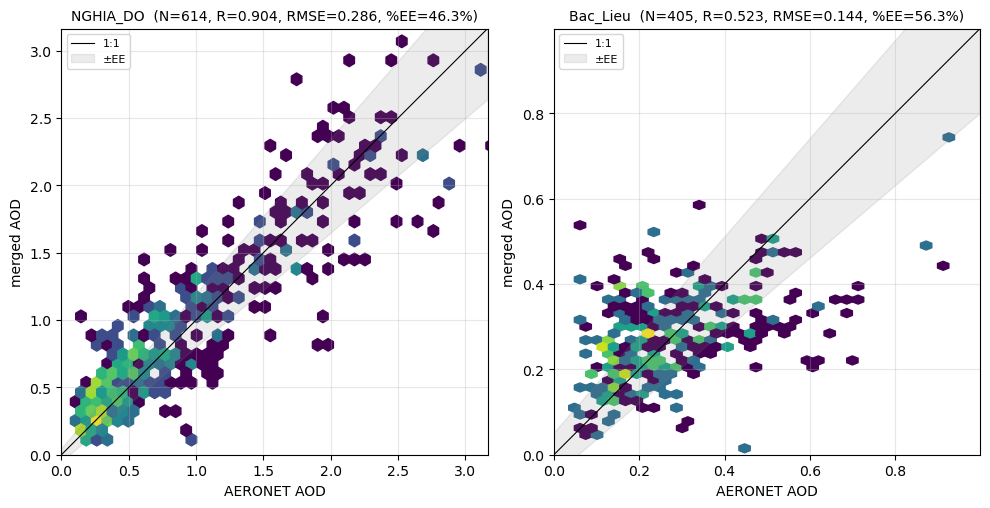

In [7]:
def _scatter(ax, sub, title):
    if len(sub) < 5:
        ax.text(0.5, 0.5, 'no pairs', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); return
    x = sub['aeronet_aod'].values
    y = sub['merged_aod'].values
    lim = max(np.nanpercentile(x, 99), np.nanpercentile(y, 99)) * 1.1
    hb  = ax.hexbin(x, y, gridsize=40, mincnt=1, bins='log', cmap='viridis')
    aer_line = np.linspace(0, lim, 100)
    ax.plot(aer_line, aer_line, 'k-', lw=0.8, label='1:1')
    ax.fill_between(aer_line,
                    aer_line - (0.05 + 0.15 * aer_line),
                    aer_line + (0.05 + 0.15 * aer_line),
                    color='gray', alpha=0.15, label='±EE')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
    ax.set_xlabel('AERONET AOD'); ax.set_ylabel('merged AOD')
    m = compute_metrics(y, x)
    ax.set_title(f'{title}  (N={m["N"]}, R={m["R"]:.3f}, RMSE={m["RMSE"]:.3f}, '
                 f'%EE={m["pct_EE"]:.1f}%)', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, len(AERONET_SITES), figsize=(5 * len(AERONET_SITES), 5))
if len(AERONET_SITES) == 1:
    axes = [axes]
for ax, site in zip(axes, AERONET_SITES):
    _scatter(ax, pairs[pairs['site'] == site], site)
fig.tight_layout(); plt.show()


### 3a. Station × season density-scatter panel

A 2 × 2 grid: rows = AERONET stations (NGHIA_DO on top, Bac_Lieu on bottom),
columns = season (dry left, wet right).  Same hex-binned scatter as §3 but
**axis limits are shared across all four panels** so dry vs wet — and
station vs station — can be compared by eye without rescaling the chart.
The wet column at Bac_Lieu typically carries the §8.1.5 wet-collapse risk
(§10 #13) and the dry rows are what the §4 `|Bias| ≤ 0.05` gate scores
against.


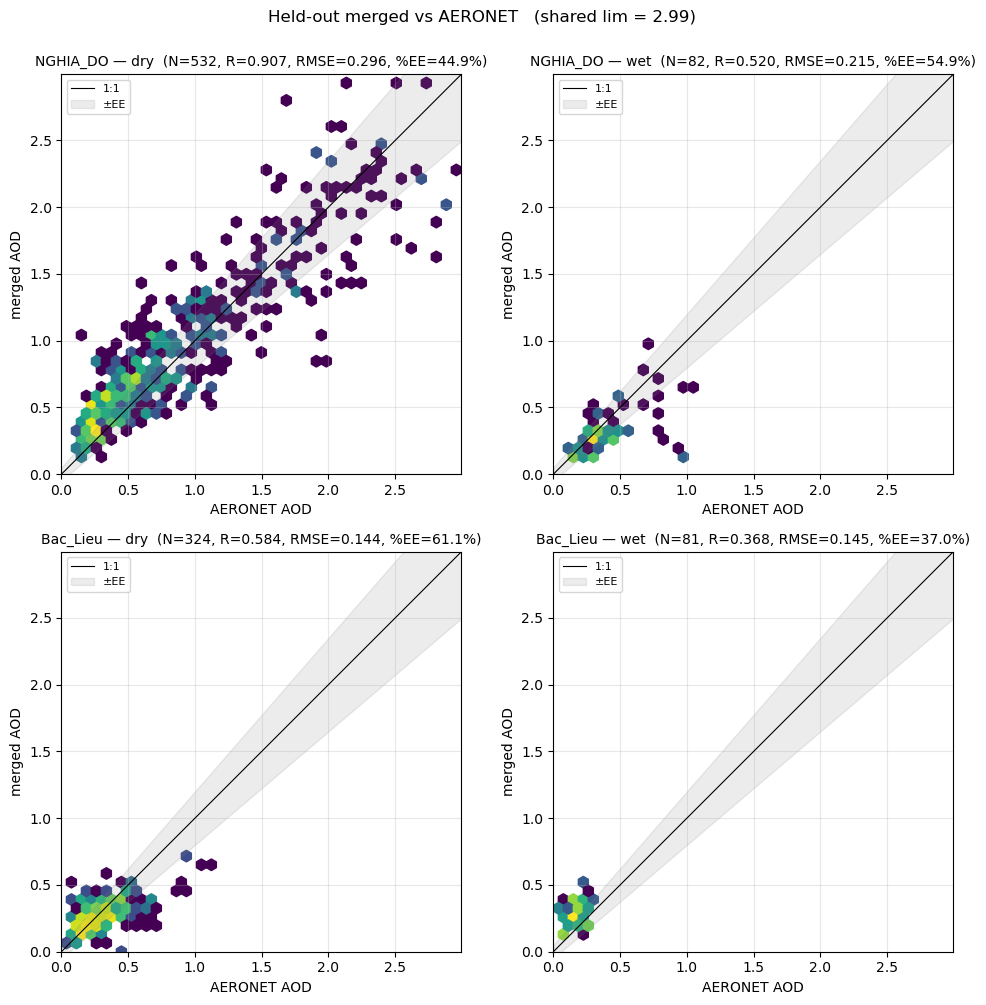

In [7]:
# 2 x 2 station x season density scatter, shared axis limits across all panels.
SEASONS = ('dry', 'wet')
ROW_SITES = list(AERONET_SITES)  # NGHIA_DO row 0, Bac_Lieu row 1

# Shared limit from the union of the 4 subsets (99th-pctile of both axes).
_x_all = pairs['aeronet_aod'].values
_y_all = pairs['merged_aod'].values
shared_lim = float(max(np.nanpercentile(_x_all, 99),
                       np.nanpercentile(_y_all, 99))) * 1.1


def _scatter_fixed_lim(ax, sub, title, lim):
    if len(sub) < 5:
        ax.text(0.5, 0.5, f'N={len(sub)}', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(title); return
    x = sub['aeronet_aod'].values
    y = sub['merged_aod'].values
    ax.hexbin(x, y, gridsize=40, mincnt=1, bins='log', cmap='viridis',
              extent=(0, lim, 0, lim))
    aer_line = np.linspace(0, lim, 100)
    ax.plot(aer_line, aer_line, 'k-', lw=0.8, label='1:1')
    ax.fill_between(aer_line,
                    aer_line - (0.05 + 0.15 * aer_line),
                    aer_line + (0.05 + 0.15 * aer_line),
                    color='gray', alpha=0.15, label=u'±EE')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
    ax.set_xlabel('AERONET AOD'); ax.set_ylabel('merged AOD')
    m = compute_metrics(y, x)
    ax.set_title(f'{title}  (N={m["N"]}, R={m["R"]:.3f}, '
                 f'RMSE={m["RMSE"]:.3f}, %EE={m["pct_EE"]:.1f}%)',
                 fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(len(ROW_SITES), len(SEASONS),
                         figsize=(5 * len(SEASONS), 5 * len(ROW_SITES)),
                         squeeze=False)
for i, site in enumerate(ROW_SITES):
    for j, season in enumerate(SEASONS):
        sub = pairs[(pairs['site'] == site) & (pairs['season'] == season)]
        _scatter_fixed_lim(axes[i][j], sub, f'{site} — {season}', shared_lim)

fig.suptitle(f'Held-out merged vs AERONET   (shared lim = {shared_lim:.2f})',
             fontsize=12, y=1.00)
fig.tight_layout(); plt.show()


## 4. §8.1.1 pass-criterion gate

The plan §8.1.1 commits three numbers per AERONET station:

* `R ≥ R_min` averaged across confidence flags ≥ 2
* `RMSE ≤ RMSE_max` averaged across confidence flags ≥ 2
* `|Bias| ≤ 0.05` in dry season at both stations

Confidence-flag = 1 (Himawari-only) is excluded from the pass criterion because
its expected behaviour is "worse than multi-sensor" — it shows up in §5 below
as part of the monotonicity check, not the headline.


In [8]:
def _site_panel(site_key: str, pairs: pd.DataFrame) -> dict:
    sub = pairs[(pairs['site'] == site_key) & (pairs['confidence_flag'] >= 2)]
    if len(sub) < 3:
        return {'N': 0, 'R': float('nan'), 'RMSE': float('nan'),
                'Bias_dry': float('nan')}
    m_all = compute_metrics(sub['merged_aod'].values, sub['aeronet_aod'].values)
    sub_d = sub[sub['season'] == 'dry']
    bias_dry = (float(np.mean(sub_d['merged_aod'] - sub_d['aeronet_aod']))
                if len(sub_d) >= 3 else float('nan'))
    return {'N': m_all['N'], 'R': m_all['R'], 'RMSE': m_all['RMSE'],
            'Bias_dry': bias_dry}

rows = []
for site_key, t in TARGETS.items():
    p = _site_panel(site_key, pairs)
    rows.append({
        'site':                 site_key,
        'N':                    p['N'],
        'R':                    p['R'],
        'R_target':             t['R_min'],
        'R_pass':               'PASS' if np.isfinite(p['R']) and p['R'] >= t['R_min'] else 'FAIL',
        'RMSE':                 p['RMSE'],
        'RMSE_target':          t['RMSE_max'],
        'RMSE_pass':            'PASS' if np.isfinite(p['RMSE']) and p['RMSE'] <= t['RMSE_max'] else 'FAIL',
        'Bias_dry':             p['Bias_dry'],
        'Bias_dry_target':      t['Bias_abs_max_dry'],
        'Bias_pass':            ('PASS' if np.isfinite(p['Bias_dry'])
                                 and abs(p['Bias_dry']) <= t['Bias_abs_max_dry']
                                 else 'FAIL'),
    })
gate = pd.DataFrame(rows).set_index('site')
gate.round(3)


,N,R,R_target,R_pass,RMSE,RMSE_target,RMSE_pass,Bias_dry,Bias_dry_target,Bias_pass
site,,,,,,,,,,
NGHIA_DO,334,0.928,0.90,PASS,0.261,0.3,PASS,0.057,0.05,FAIL
Bac_Lieu,302,0.588,0.85,FAIL,0.136,0.2,PASS,-0.018,0.05,PASS


## 5. Confidence-flag monotonicity check

§8.1.1 expects `R(flag=1) < R(flag=2) ≤ R(flag=3) ≤ R(flag=4)`.  A
non-monotonic ordering means the confidence flag is mislabelling cells and the
§7.5 inclusion rules need review.


In [9]:
monotonic_rows = []
for site in AERONET_SITES:
    by_flag = []
    for cf in (1, 2, 3, 4):
        sub = pairs[(pairs['site'] == site) & (pairs['confidence_flag'] == cf)]
        if len(sub) < 5:
            by_flag.append((cf, np.nan, len(sub)))
            continue
        m = compute_metrics(sub['merged_aod'].values, sub['aeronet_aod'].values)
        by_flag.append((cf, m['R'], m['N']))
    # Check monotonicity on the non-NaN subset
    rs = [(cf, r, n) for cf, r, n in by_flag if not np.isnan(r)]
    is_monotonic = all(rs[i][1] <= rs[i+1][1] for i in range(len(rs) - 1))
    monotonic_rows.append({
        'site':         site,
        **{f'R_flag{cf}': r for cf, r, _ in by_flag},
        **{f'N_flag{cf}': n for cf, _, n in by_flag},
        'monotonic':    'PASS' if is_monotonic else 'FAIL — review §7.5 rules',
    })
mono = pd.DataFrame(monotonic_rows).set_index('site')
mono.round(3)


,R_flag1,R_flag2,R_flag3,R_flag4,N_flag1,N_flag2,N_flag3,N_flag4,monotonic
site,,,,,,,,,
NGHIA_DO,0.874,0.93,0.958,NaN,280,292,36,6,PASS
Bac_Lieu,0.206,0.59,NaN,NaN,103,293,9,0,PASS


## 6. §8.1.5 precipitation-aware validation

`precip_aware_validation` reads `ERA5_Precip` from each slot's merged NetCDF
at the station pixel, then for every matched pair scans back 24 h in 30-min
steps to find the most recent rain event (`Precip ≥ 0.1 mm/h`).  Pairs are
binned into:

* **dry** — > 24 h since last rain (or no rain in the lookback window)
* **recovery** — 12–24 h since last rain
* **post-rain** — 0–12 h since last rain

Pass: `R ≥ 0.85` in the dry bin at both stations.  A wet-bin `R` that
collapses below 0.50 signals the §7.5 0.5× wet-season Himawari weight is
under-applied (§10 #13).


In [10]:
# precip_metrics = precip_aware_validation(pairs)
# if precip_metrics.empty:
#     print('No ERA5 precipitation data found in merged NetCDFs.\n'
#           'Ensure Stage A wrote ERA5_Precip alongside AOD_merged.')
# else:
#     cols = ['site', 'precip_bin', 'N', 'R', 'R2', 'RMSE', 'Bias', 'pct_EE']
#     print(precip_metrics[cols].round(3).to_string(index=False))


In [11]:
# # Dry-bin pass criterion
# if not precip_metrics.empty:
#     rows = []
#     for site in AERONET_SITES:
#         sub = precip_metrics[(precip_metrics['site'] == site)
#                              & (precip_metrics['precip_bin'] == 'dry')]
#         if sub.empty:
#             rows.append({'site': site, 'N': 0, 'R': np.nan,
#                          'pass': 'n/a (no dry-bin pairs)'})
#             continue
#         r = float(sub.iloc[0]['R'])
#         rows.append({'site': site, 'N': int(sub.iloc[0]['N']), 'R': r,
#                      'pass': 'PASS' if np.isfinite(r) and r >= 0.85 else 'FAIL'})
#     pd.DataFrame(rows).set_index('site').round(3)
#     display(pd.DataFrame(rows).set_index('site').round(3))

#     # Wet-collapse warning per §10 #13
#     wet_r = precip_metrics[precip_metrics['precip_bin'] == 'post-rain']
#     if not wet_r.empty:
#         low = wet_r[wet_r['R'] < 0.50]
#         if not low.empty:
#             print('\n⚠ Wet (post-rain) R < 0.50 — §7.5 wet-season Himawari weight may be under-applied:')
#             print(low[['site', 'precip_bin', 'N', 'R']].round(3).to_string(index=False))


In [12]:
# # Per-bin density scatter, using precip_label_pairs to attach bin labels.
# labelled = precip_label_pairs(pairs)
# if 'precip_bin' in labelled.columns and (labelled['precip_bin'] != 'unknown').any():
#     bins = ('dry', 'recovery', 'post-rain')
#     fig, axes = plt.subplots(len(AERONET_SITES), len(bins),
#                              figsize=(4 * len(bins), 4 * len(AERONET_SITES)),
#                              squeeze=False)
#     for i, site in enumerate(AERONET_SITES):
#         for j, bin_lbl in enumerate(bins):
#             sub = labelled[(labelled['site'] == site)
#                            & (labelled['precip_bin'] == bin_lbl)]
#             ax  = axes[i][j]
#             if len(sub) < 3:
#                 ax.text(0.5, 0.5, f'N={len(sub)}', ha='center', va='center',
#                         transform=ax.transAxes)
#                 ax.set_title(f'{site} — {bin_lbl}'); continue
#             ax.hexbin(sub['aeronet_aod'], sub['merged_aod'],
#                       gridsize=30, mincnt=1, bins='log', cmap='viridis')
#             lim = float(max(sub['aeronet_aod'].quantile(0.99),
#                             sub['merged_aod'].quantile(0.99))) * 1.1
#             ax.plot([0, lim], [0, lim], 'k:', lw=0.8)
#             ax.set_xlim(0, lim); ax.set_ylim(0, lim)
#             ax.set_xlabel('AERONET AOD'); ax.set_ylabel('merged AOD')
#             m = compute_metrics(sub['merged_aod'].values, sub['aeronet_aod'].values)
#             ax.set_title(f'{site} — {bin_lbl}  (N={m["N"]}, R={m["R"]:.2f})', fontsize=9)
#             ax.grid(alpha=0.3)
#     fig.tight_layout(); plt.show()
# else:
#     print('No precip-labelled pairs; skipping per-bin scatter.')


## 7. §8.1.4 Baseline comparison — B1 / B2 / B3

Three published-recipe baselines run against the same held-out matched pairs
from §1, evaluated with the §8.1.1 metric panel.  All three operate on the
same bias-corrected per-sensor grids stored alongside `AOD_merged` in each
slot NetCDF — what differs is the merge rule:

| Baseline | Source | Merge rule |
|---|---|---|
| **B1** — best single sensor | Plan §5.1 (VIIRS NOAA-20) | each `AOD_<sensor>` evaluated directly; best single sensor wins |
| **B2** — Gupta 2024 §4 equal-weight DT merge | *Increasing AOD spatial/temporal coverage* | arithmetic mean of valid sensors at the cell, no weighting |
| **B3** — Ahn 2021 §2.2.3 ICW | *Composite AOD over NE Asia (GEO-LEO)* | Σ wᵢ·AODᵢ with wᵢ ∝ 1/RMSEᵢ; RMSEᵢ from training-window AERONET pairs |

The thesis merged product (`AOD_merged`) wins the §8.1.4 gate if it beats
each baseline on ≥ 2 of {R, RMSE, %EE} at *at least one* (site, season) cell.

### Note on B3 — Ahn 2021 geographic overlap
Ahn 2021's published AERONET validation is over 27 sites in Northeast Asia
(Korea/Japan/E. China; their Fig. 1 shows no sites south of ~20°N).  We do
not have published Ahn-2021 numbers for Vietnam — instead we **re-apply the
recipe** (1/RMSE-weighted ICW over the same bias-corrected sensor stack) on
our domain, and per-sensor RMSEs are recomputed on the Vietnamese training
window so weights reflect local sensor skill.


In [13]:
# B3 (Ahn 2021 ICW) disabled for now — recompute B3 weights here when
# you want to re-enable it (also un-comment the b3_weights arg in the
# baseline_comparison call below).
#
# from validate import compute_per_sensor_aeronet_rmse
# b3_weights = compute_per_sensor_aeronet_rmse(TRAIN_START, TRAIN_END)
# print(f'B3 per-sensor RMSE vs AERONET on training window '
#       f'{TRAIN_START} → {TRAIN_END}:')
# for sk, rmse in sorted(b3_weights.items(), key=lambda kv: kv[1]):
#     w = (1.0 / rmse) if np.isfinite(rmse) and rmse > 0 else float('nan')
#     print(f'  {sk:22s}  RMSE = {rmse:.4f}    1/RMSE = {w:.3f}')


In [4]:
# Step 2 — score every (site, season, product) cell on the held-out pairs.
# `pairs` already comes from §1 of this notebook.  Internally,
# baseline_comparison reopens each slot NetCDF: MERGED_DIR for B1 (post-
# correction per-sensor) and GRIDDED_DIR for B2 (pre-correction
# equal-weight, the raw inputs that feed the fusion).
bc = baseline_comparison(pairs)
if bc.empty:
    print('baseline_comparison returned no rows.')
else:
    cols = ['site', 'season', 'product', 'N',
            'R', 'R2', 'RMSE', 'MAE', 'Bias', 'pct_EE']
    print(bc[cols].sort_values(['site', 'season', 'product']).round(3)
            .to_string(index=False))


    site season             product   N     R     R2  RMSE   MAE   Bias  pct_EE
Bac_Lieu    ALL     AOD_himawari_l2 142 0.263 -0.100 0.163 0.128 -0.028  46.479
Bac_Lieu    ALL     AOD_himawari_l3  20 0.771 -0.578 0.172 0.146 -0.146  40.000
Bac_Lieu    ALL     AOD_modis_maiac 218 0.547  0.275 0.144 0.109  0.009  54.128
Bac_Lieu    ALL    AOD_viirs_noaa20  53 0.628  0.369 0.133 0.095  0.021  62.264
Bac_Lieu    ALL      AOD_viirs_snpp  57 0.770  0.481 0.083 0.064  0.038  73.684
Bac_Lieu    ALL B2_equal_weight_pre 403 0.546 -0.049 0.171 0.120  0.058  54.591
Bac_Lieu    ALL              merged 405 0.523  0.257 0.144 0.107  0.002  56.296
Bac_Lieu    dry     AOD_himawari_l2 136 0.270 -0.111 0.164 0.128 -0.035  47.059
Bac_Lieu    dry     AOD_himawari_l3  20 0.771 -0.578 0.172 0.146 -0.146  40.000
Bac_Lieu    dry     AOD_modis_maiac 149 0.660  0.389 0.144 0.102 -0.039  63.087
Bac_Lieu    dry    AOD_viirs_noaa20  49 0.696  0.479 0.125 0.090  0.011  63.265
Bac_Lieu    dry      AOD_viirs_snpp  51 

### 7a. Head-to-head — does merged beat each baseline?

For every (site, season) cell, collapse B1 to its best single sensor
(per-cell, by RMSE — the sensor that *would* be picked if you knew the
truth, which is the strongest version of B1).  Then count wins of merged
vs each baseline across R / RMSE / %EE.  The §8.1.4 gate is met if there
exists a (site, season) cell where merged scores ≥ 2/3 wins against
*every* baseline.


In [15]:
if bc.empty:
    print('Skipping head-to-head — no baseline rows.')
else:
    SENSOR_KEYS = ('AOD_viirs_noaa20', 'AOD_viirs_snpp',
                   'AOD_modis_maiac',  'AOD_himawari')

    # For each (site, season) cell, identify the best B1 single sensor.
    def _best_single_sensor(grp: pd.DataFrame) -> pd.Series:
        sub = grp[grp['product'].isin(SENSOR_KEYS) & grp['RMSE'].notna()]
        if sub.empty:
            return pd.Series(dtype=float)
        return sub.loc[sub['RMSE'].idxmin()]

    rows = []
    for (site, season), grp in bc.groupby(['site', 'season']):
        merged = grp[grp['product'] == 'merged']
        if merged.empty:
            continue
        merged = merged.iloc[0]
        m_r, m_rmse, m_ee = (float(merged['R']), float(merged['RMSE']),
                             float(merged['pct_EE']))

        baselines = {}
        b1 = _best_single_sensor(grp)
        if not b1.empty:
            baselines[f'B1_{b1["product"].replace("AOD_", "")}'] = b1
        for prod in ('B2_equal_weight', 'B3_ahn2021_icw'):
            sub = grp[grp['product'] == prod]
            if not sub.empty:
                baselines[prod] = sub.iloc[0]

        for label, b in baselines.items():
            b_r, b_rmse, b_ee = float(b['R']), float(b['RMSE']), float(b['pct_EE'])
            wins = sum([
                np.isfinite(m_r)    and np.isfinite(b_r)    and m_r    > b_r,
                np.isfinite(m_rmse) and np.isfinite(b_rmse) and m_rmse < b_rmse,
                np.isfinite(m_ee)   and np.isfinite(b_ee)   and m_ee   > b_ee,
            ])
            rows.append({
                'site':     site,
                'season':   season,
                'baseline': label,
                'N':        int(b['N']),
                'ΔR':       m_r - b_r,
                'ΔRMSE':    m_rmse - b_rmse,
                'Δ%EE':     m_ee - b_ee,
                'wins/3':   f'{wins}/3',
            })
    h2h = pd.DataFrame(rows)
    print(h2h.round(3).to_string(index=False))

    # §8.1.4 pass criterion: ≥ 2/3 wins against every baseline at ≥ 1 (site, season)
    cells_pass = []
    for (site, season), grp in h2h.groupby(['site', 'season']):
        if (grp['wins/3'].str[0].astype(int) >= 2).all():
            cells_pass.append(f'{site}/{season}')
    print()
    print(f'(site, season) cells where merged ≥ 2/3 vs every baseline: '
          f'{cells_pass if cells_pass else "none"}')
    print(f'§8.1.4 pass criterion: '
          f'{"PASS" if cells_pass else "FAIL"}')


    site season       baseline  N     ΔR  ΔRMSE    Δ%EE wins/3
Bac_Lieu    ALL  B1_viirs_snpp 57 -0.246  0.061 -17.388    0/3
Bac_Lieu    dry  B1_viirs_snpp 51 -0.176  0.061 -13.399    0/3
Bac_Lieu    wet B1_modis_maiac 69  0.020  0.002   2.254    2/3
NGHIA_DO    ALL  B1_viirs_snpp 94 -0.061  0.120 -26.086    0/3
NGHIA_DO    dry  B1_viirs_snpp 82 -0.056  0.120 -25.807    0/3
NGHIA_DO    wet  B1_viirs_snpp 12  0.120  0.147 -28.455    1/3

(site, season) cells where merged ≥ 2/3 vs every baseline: ['Bac_Lieu/wet']
§8.1.4 pass criterion: PASS


### 7b. Per-station grouped bar chart — R / RMSE / %EE (season = ALL)

Headline figure for the thesis §8.1.4 table.  At each AERONET station we
plot the season-aggregated metrics for four products:

| Bar | Product key in `bc` | Description |
|---|---|---|
| VIIRS SNPP   | `AOD_viirs_snpp`      | post-correction single sensor |
| Himawari L2  | `AOD_himawari`        | post-correction single sensor |
| B2           | `B2_equal_weight_pre` | Gupta 2024 equal-weight pre-correction merge |
| **Merged**   | `merged`              | thesis TC-weighted product |

Three panels — one per metric — because R, RMSE, and %EE live on
incompatible scales.  Arrows in the panel titles encode “better”
direction so a reader can scan the figure without reading the caption.


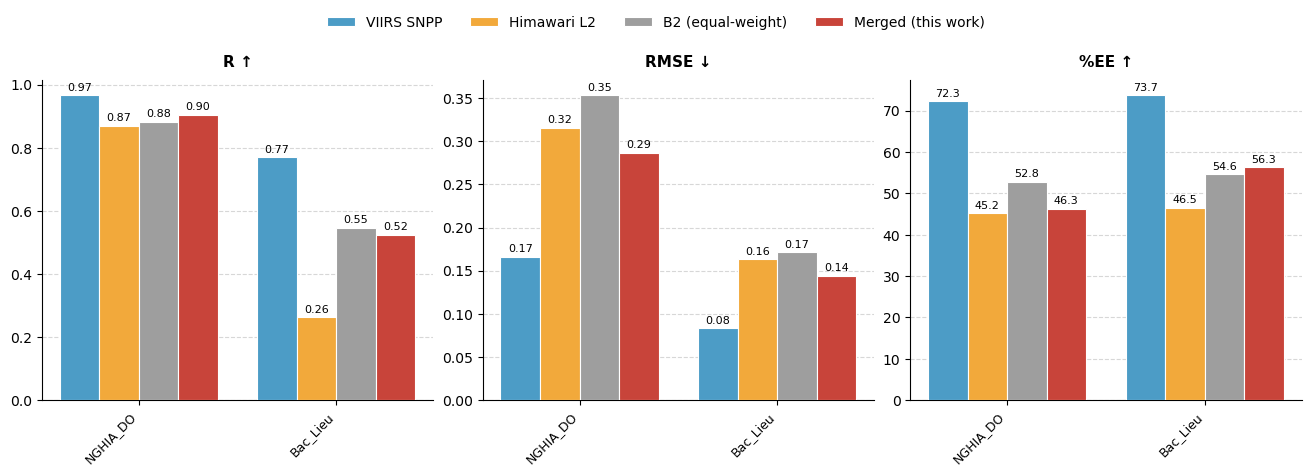


Paste-ready Markdown table:

| Site | Product | R | RMSE | pct_EE | N |
|---|---|---|---|---|---|
| NGHIA_DO | VIIRS SNPP | 0.966 | 0.166 | 72.3 | 94 |
| NGHIA_DO | Himawari L2 | 0.870 | 0.316 | 45.2 | 418 |
| NGHIA_DO | B2 (equal-weight) | 0.883 | 0.353 | 52.8 | 608 |
| NGHIA_DO | Merged (this work) | 0.904 | 0.286 | 46.3 | 614 |
| Bac_Lieu | VIIRS SNPP | 0.770 | 0.083 | 73.7 | 57 |
| Bac_Lieu | Himawari L2 | 0.263 | 0.163 | 46.5 | 142 |
| Bac_Lieu | B2 (equal-weight) | 0.546 | 0.171 | 54.6 | 403 |
| Bac_Lieu | Merged (this work) | 0.523 | 0.144 | 56.3 | 405 |


In [8]:
# ---- 7b. Grouped bar chart: R / RMSE / %EE per station (season=ALL) ----
# Built from `bc` (output of baseline_comparison in cell 25).  We pick the
# season-aggregated rows ("ALL") and the four products requested for the
# thesis figure.

PRODUCTS = [
    ("AOD_viirs_snpp",      "VIIRS SNPP"),
    ("AOD_himawari_l2",        "Himawari L2"),
    ("B2_equal_weight_pre", "B2 (equal-weight)"),
    ("merged",              "Merged (this work)"),
]
PRODUCT_KEYS   = [p[0] for p in PRODUCTS]
PRODUCT_LABELS = [p[1] for p in PRODUCTS]
METRICS = [
    ("R",       "R ↑"),       # higher is better
    ("RMSE",    "RMSE ↓"),    # lower  is better
    ("pct_EE",  "%EE ↑"),     # higher is better
]

# Season-aggregated subset.  `baseline_comparison` writes season='ALL' rows
# alongside the per-season rows (see validate.py L854-L863).
bar_df = (bc[(bc["season"] == "ALL") & bc["product"].isin(PRODUCT_KEYS)]
            .copy())

# Pivot into (site, product) -> metric value, ordered so plotting is trivial.
sites = list(AERONET_SITES)
pivot = {met: bar_df.pivot(index="site", columns="product", values=met)
                       .reindex(index=sites, columns=PRODUCT_KEYS)
         for met, _ in METRICS}

# Colour-blind safe palette; the thesis product is the dark highlight.
COLORS = ["#4C9CC6",  # VIIRS SNPP   — light blue
          "#F2A93B",  # Himawari L2  — amber
          "#9E9E9E",  # B2           — neutral grey
          "#C8443A"]  # merged       — accent red

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)

bar_w = 0.20
x = np.arange(len(sites))
# Calculate symmetric offsets so groups center on the x-tick
offsets = (np.arange(len(PRODUCT_KEYS)) - (len(PRODUCT_KEYS)-1)/2) * bar_w

for i, (ax, (metric_key, title)) in enumerate(zip(axes, METRICS)):
    # Thesis styling: subtle y-grid behind the bars for readability
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    
    for j, (prod_key, prod_lbl) in enumerate(PRODUCTS):
        # Determine format based on metric (2 decimals for R/RMSE, 1 for %EE)
        fmt = "%.1f" if metric_key == "pct_EE" else "%.2f"
        
        # Only add labels to the legend on the very first axes to prevent duplicates
        label = prod_lbl if i == 0 else ""
        
        bars = ax.bar(
            x + offsets[j], 
            pivot[metric_key][prod_key].values, 
            width=bar_w,
            color=COLORS[j], 
            label=label,
            zorder=3,           # Ensure bars sit on top of grid
            edgecolor="white",  # Crisp visual separation
            linewidth=0.8
        )
        
        # Annotate bars with numeric values
        ax.bar_label(bars, fmt=fmt, padding=2, fontsize=8)
    
    # Format axes and titles
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xticks(x)
    # Using 'sites' for x-labels as each group represents a station
    ax.set_xticklabels(sites, rotation=45, ha="right", fontsize=9)
    
    # Despine for a cleaner, publication-ready look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Shared legend placed at the top center of the figure
fig.legend(
    loc="lower center", 
    bbox_to_anchor=(0.5, 1.02), # Sits nicely between the super-title and sub-titles
    ncol=4, 
    frameon=False, 
    fontsize=10
)

# fig.suptitle("Held-out AERONET validation — season aggregated (ALL)",
#              fontsize=12)
plt.show()

# Print the underlying numbers in a paste-ready Markdown table for the thesis.
print()
print("Paste-ready Markdown table:")
print()
hdr = "| Site | Product | " + " | ".join(m for m, _ in METRICS) + " | N |"
sep = "|" + "|".join(["---"] * (3 + len(METRICS))) + "|"
print(hdr); print(sep)
for site in sites:
    for prod_key, prod_lbl in PRODUCTS:
        row = bar_df[(bar_df["site"] == site) & (bar_df["product"] == prod_key)]
        if row.empty: continue
        row = row.iloc[0]
        print(f"| {site} | {prod_lbl} | "
              f"{row['R']:.3f} | {row['RMSE']:.3f} | {row['pct_EE']:.1f} | "
              f"{int(row['N'])} |")
